# Shower rates v1

In [10]:
import uproot
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

import sys
sys.path.append("../")
from utils.py_plot_functions import plot_station_wheel_profile
from utils.functions import stations

plt.style.use(hep.styles.CMS)

In [11]:
scale_sbxfix = (1/1929240) * 2760 * 11246
scale = (1/1565520) * 2760 * 11246

In [12]:
histos_thr_6 = uproot.open("histograms/rates_v1/histograms_thr6.root")
histos_thr_12 = uproot.open("histograms/rates_v1/histograms_thr12.root")
histos_thr_14 = uproot.open("histograms/rates_v1/histograms_thr14.root")
histos_thr_24 = uproot.open("histograms/rates_v1/histograms_thr24.root")

histos_sbxfix_thr6 = uproot.open("histograms/rates_v1/histograms_sbxfix_thr6.root")

In [17]:
data = {
    "thr6": np.array([histos_thr_6["Rate_allBX_MB{st}_FwShower".format(st=st)].values() * scale for st in stations]).flatten(),
    "thr12": np.array([histos_thr_12["Rate_allBX_MB{st}_FwShower".format(st=st)].values() * scale for st in stations]).flatten(),
    "thr14": np.array([histos_thr_14["Rate_allBX_MB{st}_FwShower".format(st=st)].values() * scale for st in stations]).flatten(),
    "thr24": np.array([histos_thr_24["Rate_allBX_MB{st}_FwShower".format(st=st)].values() * scale for st in stations]).flatten(),
}
data_AM_allbx = np.array([histos_thr_6["Rate_allBX_MB{st}_AM".format(st=st)].values() * scale_sbxfix for st in stations]).flatten()
data_AM_goodbx = np.array([histos_thr_6["Rate_goodBX_MB{st}_AM".format(st=st)].values() * scale_sbxfix for st in stations]).flatten()
data_sbxfix_thr6_allbx = np.array([histos_sbxfix_thr6["Rate_allBX_MB{st}_FwShower".format(st=st)].values() * scale_sbxfix for st in stations]).flatten()
data_sbxfix_thr6_goodbx = np.array([histos_sbxfix_thr6["Rate_goodBX_MB{st}_FwShower".format(st=st)].values() * scale_sbxfix for st in stations]).flatten()


### Threshold scan

[]

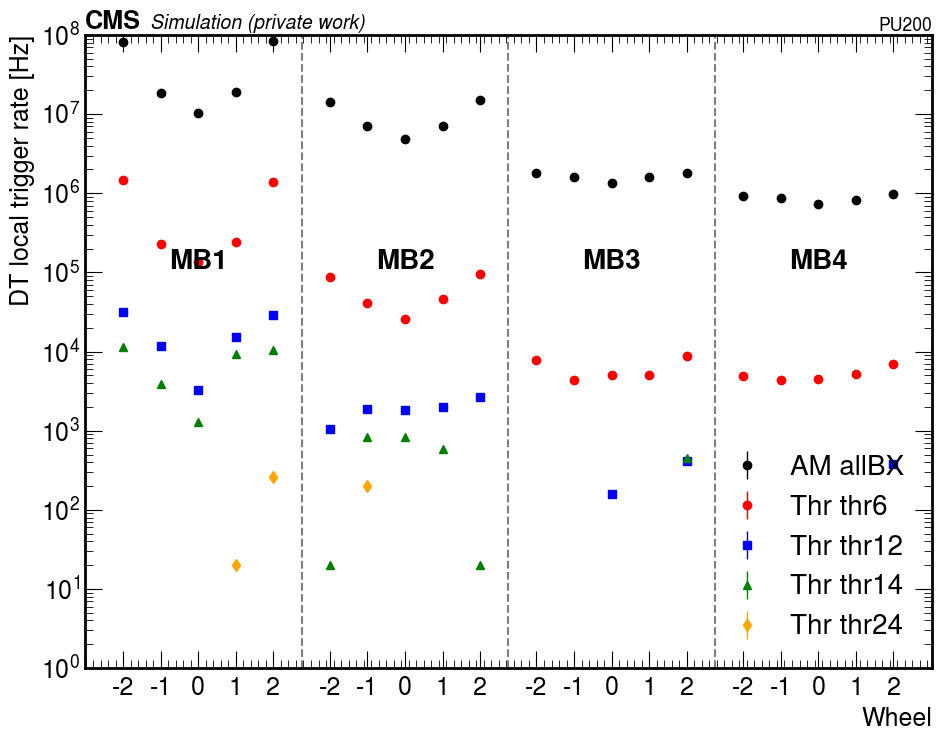

In [18]:
profile_plot_kwargs = {
    "st_label_y": 1e5,
    "st_labels_kwargs": {"fontsize": 20, "fontweight": "bold", "ha": "center"},
    "tick_params_kwargs": {"labelsize": 18},
    "cms_label_kwargs": {"text": "(private work)", "data": False, "rlabel": "PU200", "fontsize": 14},
    "xlabel_kwargs": {"fontsize": 12},
}

fig, ax = plt.subplots(figsize=(10, 8))

plot_station_wheel_profile(data_AM_allbx, ax=ax, errors=None, plot_kwargs={"label": "AM allBX", "fmt": "o", "color": "k", "elinewidth": 1, "capsize": 0}, **profile_plot_kwargs)

markers = ["o", "s", "^", "d"]
colors = ["r", "b", "g", "orange"]

for i, (thr, data) in enumerate(data.items()):
    plot_kwargs = {
        "label": "Thr " + thr,
        "fmt": markers[i],
        "color": colors[i],
        "elinewidth": 1,
        "capsize": 0,
    }
    plot_station_wheel_profile(data, ax=ax, errors=None, plot_kwargs=plot_kwargs, **profile_plot_kwargs)

ax.set_yscale('log')
ax.set_ylim(1, 1e8)
ax.set_ylabel("DT local trigger rate [Hz]", fontsize=18)
ax.set_xlabel("Wheel", fontsize=18)

ax.legend(loc='best', fontsize=20)
plt.tight_layout()

plt.plot()

### Showers Rate

[]

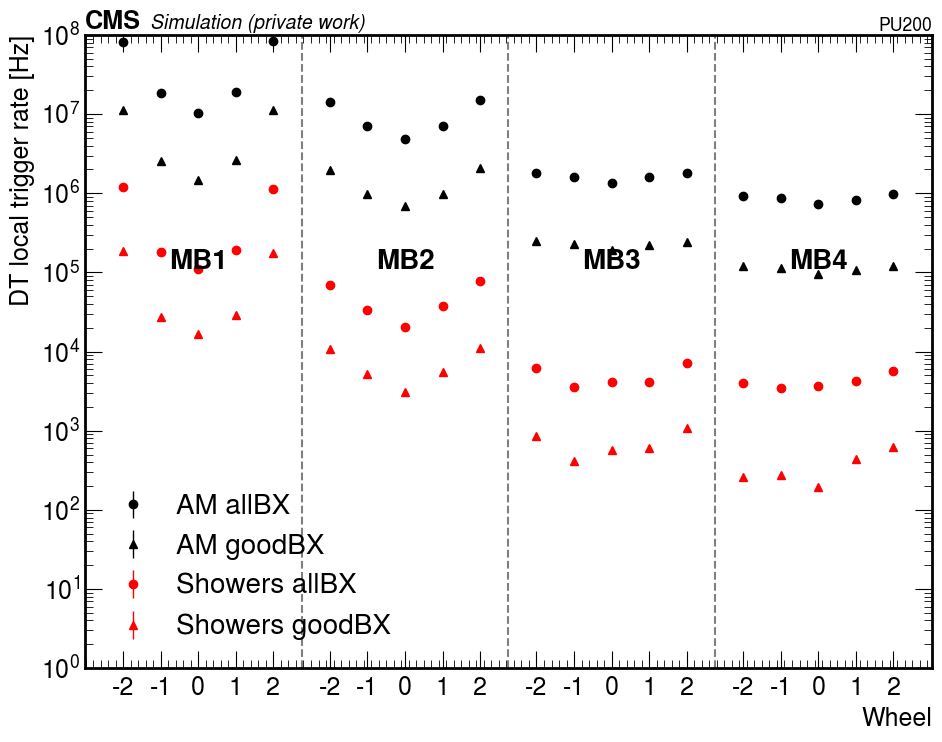

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

plot_station_wheel_profile(
    data_AM_allbx,
    ax=ax,
    errors=None,
    plot_kwargs={"label": "AM allBX", "fmt": "o", "color": "k", "elinewidth": 1, "capsize": 0}, 
    **profile_plot_kwargs
)
plot_station_wheel_profile(
    data_AM_goodbx,
    ax=ax,
    errors=None,
    plot_kwargs={"label": "AM goodBX", "fmt": "^", "color": "k", "elinewidth": 1, "capsize": 0},
    **profile_plot_kwargs
)
plot_station_wheel_profile(
    data_sbxfix_thr6_allbx,
    ax=ax,
    errors=None,
    plot_kwargs={"label": "Showers allBX", "fmt": "o", "color": "r", "elinewidth": 1, "capsize": 0},
    **profile_plot_kwargs
)
plot_station_wheel_profile(
    data_sbxfix_thr6_goodbx,
    ax=ax,
    errors=None,
    plot_kwargs={"label": "Showers goodBX", "fmt": "^", "color": "r", "elinewidth": 1, "capsize": 0},
    **profile_plot_kwargs
)


ax.set_yscale('log')
ax.set_ylim(1, 1e8)
ax.set_ylabel("DT local trigger rate [Hz]", fontsize=18)
ax.set_xlabel("Wheel", fontsize=18)

ax.legend(loc='best', fontsize=20)
plt.tight_layout()

plt.plot()